# Module 4: Fine-tuning FinBERT for financial sentiment

This trains the sentiment model that feeds the trading agent. It fine-tunes FinBERT on the Financial
PhraseBank, evaluates it, checks how it generalizes to informal tweets, and shows the directional
sentiment score the rest of the system uses.

**Runtime:** set a GPU first (Runtime > Change runtime type > T4 GPU). Training takes a few minutes.

The heavy lifting lives in `src/sentinel/models/sentiment/`; this notebook just calls it.

In [1]:
!pip -q install "transformers<4.46.0" evaluate accelerate scikit-learn "datasets<3.0"

import os, sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/rdhanase/sentinel-agentic-trading.git"
REPO_DIR = "sentinel-agentic-trading"

if IN_COLAB:
    if not pathlib.Path(REPO_DIR).exists():
        subprocess.run(["git", "clone", "--branch", "dev", REPO_URL], check=True)
    os.chdir(REPO_DIR)

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import torch
print("GPU available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 38.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
GPU available: True


In [2]:
from sentinel.models.sentiment.finetune import finetune
from sentinel.models.sentiment.data import LABELS, load_twitter_ood
from sentinel.models.sentiment.infer import SentimentScorer

## Fine-tune

Four epochs on the 66%-agreement Financial PhraseBank. The function returns the trainer, the tokenized
splits, and the held-out test metrics.

In [3]:
trainer, enc, metrics = finetune(epochs=4, agreement="sentences_66agree")
print({k: round(v, 4) for k, v in metrics.items() if isinstance(v, float)})

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Map:   0%|          | 0/3373 [00:00<?, ? examples/s]

Map:   0%|          | 0/422 [00:00<?, ? examples/s]

Map:   0%|          | 0/422 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.290200,0.284198,0.905213,0.883543
2,0.161600,0.301164,0.898104,0.882351
3,0.071600,0.327643,0.917062,0.900460
4,0.025200,0.337979,0.917062,0.898060


{'eval_loss': 0.3734, 'eval_accuracy': 0.91, 'eval_macro_f1': 0.8977, 'eval_runtime': 1.7365, 'eval_samples_per_second': 243.019, 'eval_steps_per_second': 8.062, 'epoch': 4.0}


## Evaluate on the held-out test set

Accuracy alone hides the neutral-heavy skew, so look at the per-class report and the confusion matrix.

              precision    recall  f1-score   support

    negative       0.88      0.88      0.88        51
     neutral       0.92      0.93      0.93       254
    positive       0.89      0.87      0.88       117

    accuracy                           0.91       422
   macro avg       0.90      0.90      0.90       422
weighted avg       0.91      0.91      0.91       422



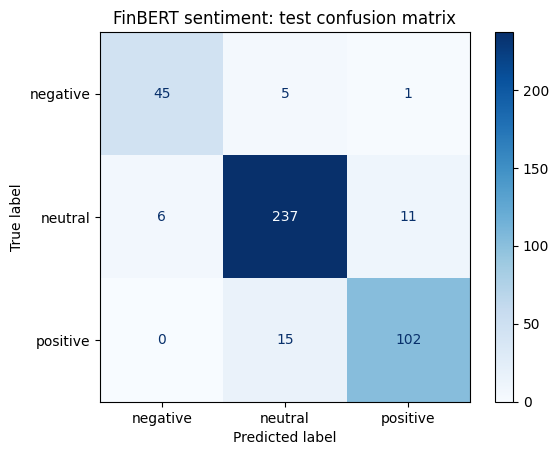

In [4]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred = trainer.predict(enc["test"])
y_pred = pred.predictions.argmax(-1)
y_true = pred.label_ids
print(classification_report(y_true, y_pred, target_names=LABELS))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=LABELS, cmap="Blues")
plt.title("FinBERT sentiment: test confusion matrix"); plt.show()

## Out-of-distribution check

The model was trained on formal analyst-style sentences. Tweets are messier, so this is a fair test of
whether it generalizes.

In [5]:
from sklearn.metrics import accuracy_score, f1_score

ood = load_twitter_ood()
scorer = SentimentScorer("models_store/finbert-sentiment")
probs = scorer.predict_proba(list(ood["text"]))
yp = probs.argmax(-1)
print("OOD accuracy:", round(accuracy_score(ood["labels"], yp), 4),
      "| macro-F1:", round(f1_score(ood["labels"], yp, average="macro"), 4))

sent_train.csv: 0.00B [00:00, ?B/s]

sent_valid.csv: 0.00B [00:00, ?B/s]

OOD accuracy: 0.7546 | macro-F1: 0.6889


## The signal the agent consumes

Downstream, the risk/decision agent does not want three probabilities, it wants one number. `score`
returns P(positive) - P(negative), in [-1, 1].

In [6]:
headlines = [
    "Company beats earnings expectations and raises full-year guidance",
    "Regulators open a fraud probe into the firm as shares tumble",
    "Stock little changed as investors await the Fed decision",
]
for h, s in zip(headlines, scorer.score(headlines)):
    print(f"{s:+.2f}   {h}")

+0.99   Company beats earnings expectations and raises full-year guidance
-0.28   Regulators open a fraud probe into the firm as shares tumble
+0.06   Stock little changed as investors await the Fed decision


## Save the model

Keep the fine-tuned weights in Drive so the later notebooks can load them without retraining.

In [7]:
# from google.colab import drive; drive.mount('/content/drive')
# import shutil
# shutil.copytree('models_store/finbert-sentiment',
#                 '/content/drive/MyDrive/sentinel/finbert-sentiment', dirs_exist_ok=True)

**Next (Module 5):** train the volatility circuit-breaker on the price dataset and compare a neural
classifier against an XGBoost baseline, then wire both models into the agent.